# Imports

In [1]:
import torch

import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm

from copy import deepcopy
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

### Set seed and device

In [2]:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

Device in use: cuda


# Load Dataset

In [3]:
# Method to load 9 sets of inertial data and combine to create a dataset
def load_inertial_data(fileName: str, split: str) :
  df = pd.read_csv(f"./data/UCI HAR Dataset/{split}/Inertial Signals/{fileName}_{split}.txt", sep=r"\s+", header=None)
  return df

In [4]:
file_list = [
    "body_acc_x",
    "body_gyro_x",
    "total_acc_x",
    "body_acc_y",
    "body_gyro_y",
    "total_acc_y",
    "body_acc_z",
    "body_gyro_z",
    "total_acc_z"
]

# Add rows for split and columns for files
df_train = None
df_test = None
for file in file_list:
  if df_train is None:
    df_train = load_inertial_data(file, "train")
  else :
    df_train = pd.concat([df_train, load_inertial_data(file, "train")], axis=1)
  
  if df_test is None:
    df_test = load_inertial_data(file, "test")
  else:
    df_test = pd.concat([df_test, load_inertial_data(file, "test")], axis=1)

df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
print(f"Shape of the dataset: {df.shape}")
df.head()

Shape of the dataset: (10299, 1152)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572,...,0.100058,0.098564,0.093177,0.088742,0.090505,0.094843,0.098350,0.100385,0.099874,0.094987
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363,...,0.094537,0.098759,0.101977,0.095360,0.089466,0.095126,0.099496,0.093535,0.089035,0.090612
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946,...,0.085343,0.087155,0.084546,0.082166,0.081972,0.081413,0.081936,0.083011,0.082334,0.081487
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483,...,0.088112,0.087322,0.083738,0.082701,0.084490,0.082785,0.084084,0.085761,0.083275,0.081404
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175,...,0.088028,0.090312,0.088713,0.086957,0.086522,0.081640,0.079652,0.081329,0.085397,0.088816


In [5]:
data_Subject_train = pd.read_csv("./data/UCI HAR Dataset/train/subject_train.txt", sep=r"\s+", header=None)
data_y_train = pd.read_csv("./data/UCI HAR Dataset/train/y_train.txt", sep=r"\s+", header=None)

data_Subject_test = pd.read_csv("./data/UCI HAR Dataset/test/subject_test.txt", sep=r"\s+", header=None)
data_y_test = pd.read_csv("./data/UCI HAR Dataset/test/y_test.txt", sep=r"\s+", header=None)

data_Subject = pd.concat([data_Subject_train, data_Subject_test], axis=0).reset_index(drop=True)
data_y = pd.concat([data_y_train, data_y_test], axis=0).reset_index(drop=True)

In [6]:
unique_subjects = data_Subject[0].unique()
np.random.shuffle(unique_subjects)

# Split subjects
train_subjects = unique_subjects[:20]
validation_subjects = unique_subjects[20:25]
test_subjects = unique_subjects[25:30]

print(f"Number of training subjects: {len(train_subjects)}")
print(f"Number of validation subjects: {len(validation_subjects)}")
print(f"Number of test subjects: {len(test_subjects)}")

Number of training subjects: 20
Number of validation subjects: 5
Number of test subjects: 5


## EDA

Training set class distribution:
0
1    1722
2    1544
3    1406
4    1777
5    1906
6    1944
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_24044\4161944681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_y[0], palette='viridis')


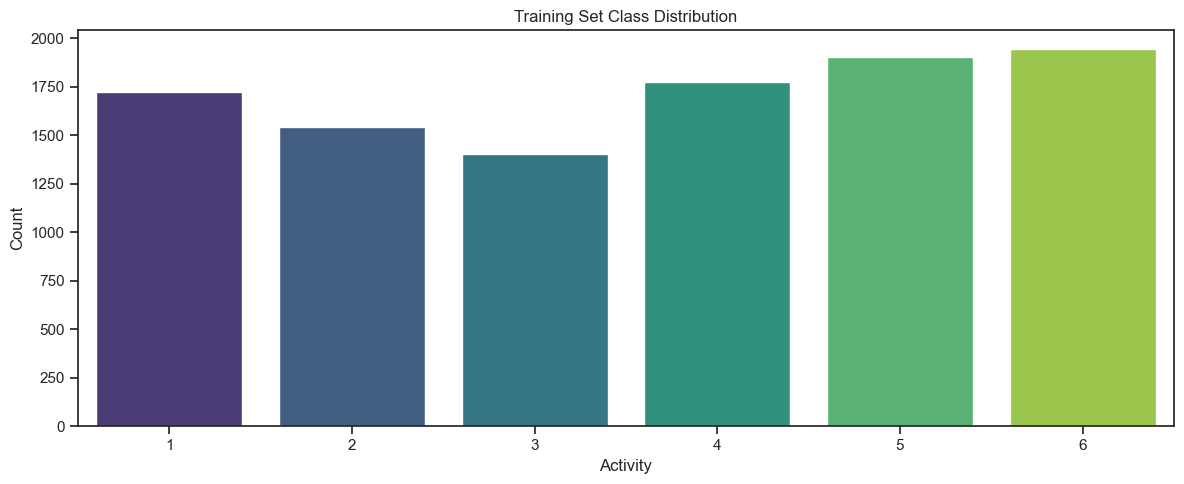

In [7]:
# Class distribution of the dataset
print("Training set class distribution:")
print(data_y[0].value_counts().sort_index())

plt.figure(figsize=(12, 5))

sns.countplot(x=data_y[0], palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
print("Shape of X_combined:", df.shape)
print("Shape of y_combined:", data_y.shape)
print("Shape of subjects_combined:", data_Subject.shape)

Shape of X_combined: (10299, 1152)
Shape of y_combined: (10299, 1)
Shape of subjects_combined: (10299, 1)


In [9]:
train_indices = data_Subject[data_Subject[0].isin(train_subjects)].index
X_train_final = df.loc[train_indices].reset_index(drop=True)
y_train_final = data_y.loc[train_indices].reset_index(drop=True)

validation_indices = data_Subject[data_Subject[0].isin(validation_subjects)].index
X_val_final = df.loc[validation_indices].reset_index(drop=True)
y_val_final = data_y.loc[validation_indices].reset_index(drop=True)

test_indices = data_Subject[data_Subject[0].isin(test_subjects)].index
X_test_final = df.loc[test_indices].reset_index(drop=True)
y_test_final = data_y.loc[test_indices].reset_index(drop=True)

# Make labels 0-indexed
y_train_final = y_train_final - 1
y_val_final = y_val_final - 1
y_test_final = y_test_final - 1

print(f"Shape of X_train_final: {X_train_final.shape}")
print(f"Shape of y_train_final: {y_train_final.shape}")
print(f"Shape of X_val_final: {X_val_final.shape}")
print(f"Shape of y_val_final: {y_val_final.shape}")
print(f"Shape of X_test_final: {X_test_final.shape}")
print(f"Shape of y_test_final: {y_test_final.shape}")

Shape of X_train_final: (6801, 1152)
Shape of y_train_final: (6801, 1)
Shape of X_val_final: (1775, 1152)
Shape of y_val_final: (1775, 1)
Shape of X_test_final: (1723, 1152)
Shape of y_test_final: (1723, 1)


## PreProcessing

In [10]:
# Standardize the data using min max scaler to scale data from 0 to 1
scaler = MinMaxScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_final_scaled = scaler.transform(X_val_final)
X_test_final_scaled = scaler.transform(X_test_final)

## Create Dataloaders

In [11]:
# Reshape the data: (N, 1152) -> (N, 9, 128) -> (N, 128, 9)
X_train_res = X_train_final_scaled.reshape(-1, 9, 128).transpose(0, 2, 1)
X_val_res = X_val_final_scaled.reshape(-1, 9, 128).transpose(0, 2, 1)
X_test_res = X_test_final_scaled.reshape(-1, 9, 128).transpose(0, 2, 1)

print("Reshaped X_train:", X_train_res.shape)
print("Reshaped X_val:", X_val_res.shape)
print("Reshaped X_test:", X_test_res.shape)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final.values.squeeze(), dtype=torch.long)

X_val_tensor = torch.tensor(X_val_res, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_final.values.squeeze(), dtype=torch.long)

X_test_tensor = torch.tensor(X_test_res, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_final.values.squeeze(), dtype=torch.long)

# Create Datasets and DataLoaders
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Reshaped X_train: (6801, 128, 9)
Reshaped X_val: (1775, 128, 9)
Reshaped X_test: (1723, 128, 9)


# Custom GRU

In [12]:
class CustomGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(CustomGRUCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Reset gate (r)
        self.w_ir = nn.Linear(input_size, hidden_size)
        self.w_hr = nn.Linear(hidden_size, hidden_size)
        
        # Update gate (z)
        self.w_iz = nn.Linear(input_size, hidden_size)
        self.w_hz = nn.Linear(hidden_size, hidden_size)
        
        # New gate (n) / Candidate hidden state
        self.w_in = nn.Linear(input_size, hidden_size)
        self.w_hn = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        # Update gate
        z = torch.sigmoid(self.w_iz(x) + self.w_hz(h))
        # Reset gate
        r = torch.sigmoid(self.w_ir(x) + self.w_hr(h))
        # New / Candidate Gate
        n = torch.tanh(self.w_in(x) + r * self.w_hn(h))
        # Hidden state update
        h_next = (1 - z) * n + z * h
        return h_next


class CustomGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(CustomGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.cells = nn.ModuleList([
            CustomGRUCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):

        batch_size, seq_len, _ = x.size()
        
        # Initialize hidden states for all layers
        h = [torch.zeros(batch_size, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        
        # Process sequence
        for t in range(seq_len):
            x_t = x[:, t, :]
            
            for layer in range(self.num_layers):
                h[layer] = self.cells[layer](x_t, h[layer])
                x_t = h[layer]
                
                if layer < self.num_layers - 1:
                    x_t = self.dropout(x_t)
                    
        out = self.fc(self.dropout(h[-1]))
        return out

# Hyperparameters
INPUT_SIZE = 9
HIDDEN_SIZE = 64
NUM_LAYERS = 2
NUM_CLASSES = 6
DROPOUT = 0.4
EPOCHS = 50
LEARNING_RATE = 1e-4

# Initialize model
custom_model = CustomGRU(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(custom_model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


## Train

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=EPOCHS):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_path = 'best_custom_gru.pth'
    
    epoch_pbar = tqdm(range(num_epochs), desc='Training Custom GRU')
    for epoch in epoch_pbar:
        
        model.train()
        running_loss = 0.0
        
        batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False)
        for inputs, labels in batch_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        scheduler.step(epoch_val_loss)
        
        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), best_model_path)
            
        epoch_pbar.set_postfix({'Train Loss': f'{epoch_train_loss:.4f}', 'Val Loss': f'{epoch_val_loss:.4f}'})

    model.load_state_dict(torch.load(best_model_path))
    tqdm.write(f'Training complete. Best Val Loss: {best_val_loss:.4f}')
    return train_losses, val_losses, model

custom_train_losses, custom_val_losses, custom_model = train_model(
    custom_model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=EPOCHS
)

Training Custom GRU:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/107 [00:00<?, ?it/s]

...

Epoch 47:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 48:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 49:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 50:   0%|          | 0/107 [00:00<?, ?it/s]

Training complete. Best Val Loss: 0.5400


### Plotting

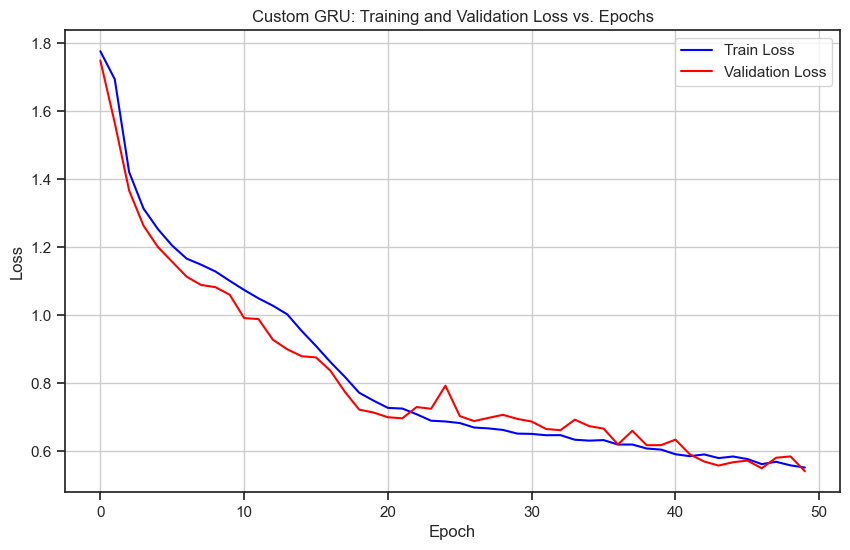

In [14]:
plt.figure(figsize=(10,6))
plt.plot(custom_train_losses, label='Train Loss', color='blue')
plt.plot(custom_val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Custom GRU: Training and Validation Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()

Evaluating Test (Custom GRU):   0%|          | 0/27 [00:00<?, ?it/s]

--- Test (Custom GRU) Set Metrics ---
Weighted Precision: 0.7493
Weighted Recall:    0.7348


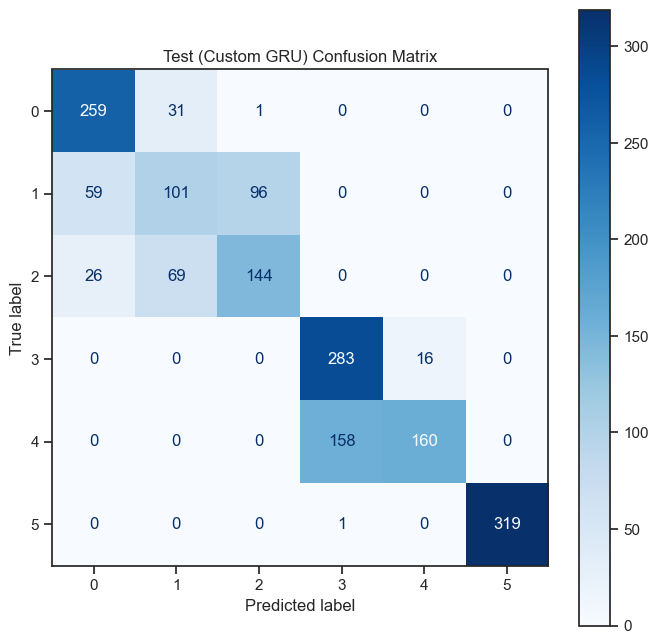

In [15]:
def evaluate_model(model, data_loader, set_name="Test"):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc=f'Evaluating {set_name}'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"--- {set_name} Set Metrics ---")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall:    {recall:.4f}")
    
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f'{set_name} Confusion Matrix')
    plt.show()
    
    return {'precision': precision, 'recall': recall}

# Evaluate the Custom GRU model on Test set
custom_metrics = evaluate_model(custom_model, test_loader, "Test (Custom GRU)")

## PyTorch Implementation

In [16]:
class PyTorchGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(PyTorchGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # PyTorch native GRU
        self.gru = nn.GRU(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.gru(x, h0)

        out = self.dropout(out[:, -1, :])
        
        out = self.fc(out)
        return out

In [17]:
# Initialize PyTorch GRU Model
pytorch_model = PyTorchGRU(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)

criterion_pt = nn.CrossEntropyLoss()
optimizer_pt = torch.optim.AdamW(pytorch_model.parameters(), lr=LEARNING_RATE)
scheduler_pt = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_pt, mode='min', factor=0.5, patience=3)

In [18]:
def train_pt_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=EPOCHS):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_path = 'best_pytorch_gru.pth'
    
    epoch_pbar = tqdm(range(num_epochs), desc='Training PyTorch GRU')
    for epoch in epoch_pbar:
        model.train()
        running_loss = 0.0
        
        batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False)
        for inputs, labels in batch_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        
        scheduler.step(epoch_val_loss)
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), best_model_path)
            
        epoch_pbar.set_postfix({'Train Loss': f'{epoch_train_loss:.4f}', 'Val Loss': f'{epoch_val_loss:.4f}'})

    model.load_state_dict(torch.load(best_model_path))
    tqdm.write(f'Training complete. Best Val Loss: {best_val_loss:.4f}')
    return train_losses, val_losses, model

pt_train_losses, pt_val_losses, pytorch_model = train_pt_model(
    pytorch_model, train_loader, val_loader, criterion_pt, optimizer_pt, scheduler_pt, num_epochs=EPOCHS
)

Training PyTorch GRU:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/107 [00:00<?, ?it/s]

...

Epoch 47:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 48:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 49:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 50:   0%|          | 0/107 [00:00<?, ?it/s]

Training complete. Best Val Loss: 0.5317


### Plot

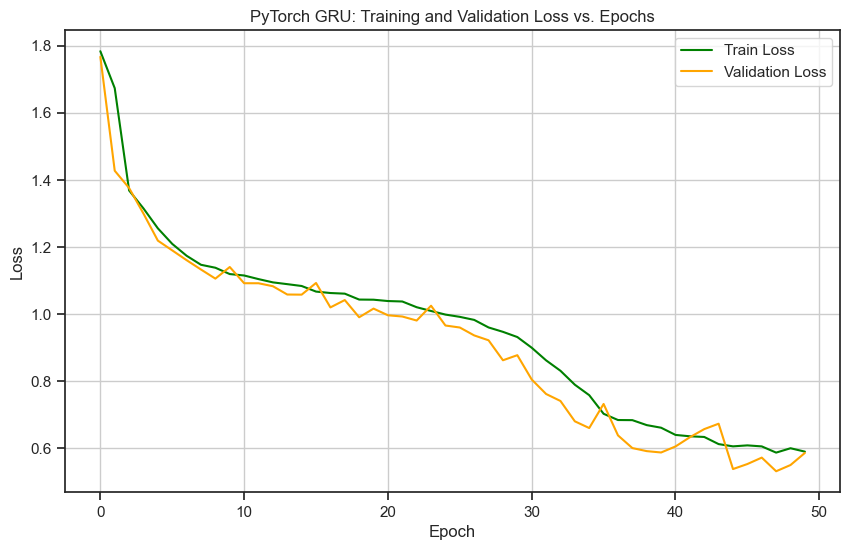

In [19]:
plt.figure(figsize=(10,6))
plt.plot(pt_train_losses, label='Train Loss', color='green')
plt.plot(pt_val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch GRU: Training and Validation Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()

Evaluating Test (PyTorch GRU):   0%|          | 0/27 [00:00<?, ?it/s]

--- Test (PyTorch GRU) Set Metrics ---
Weighted Precision: 0.7644
Weighted Recall:    0.7174


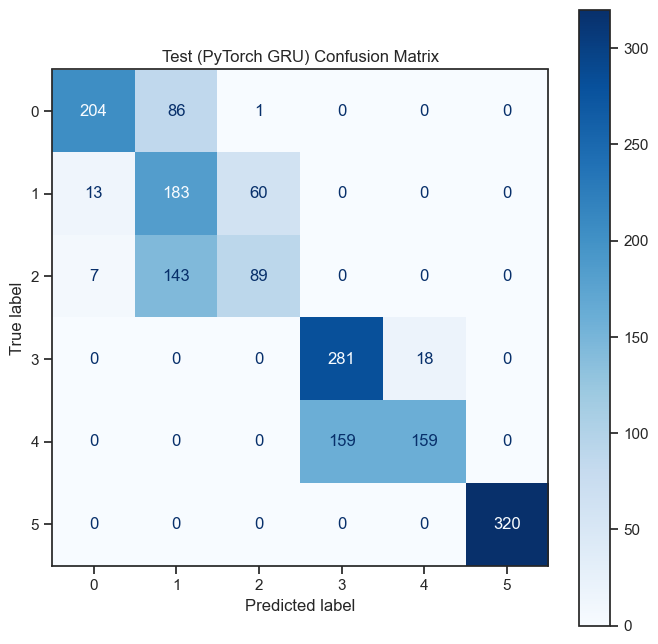

In [20]:
# Evaluate the PyTorch GRU model on Test set
pytorch_metrics = evaluate_model(pytorch_model, test_loader, "Test (PyTorch GRU)")

# Comparison

   Metric  Custom GRU  PyTorch GRU
Precision    0.749315     0.764450
   Recall    0.734765     0.717353


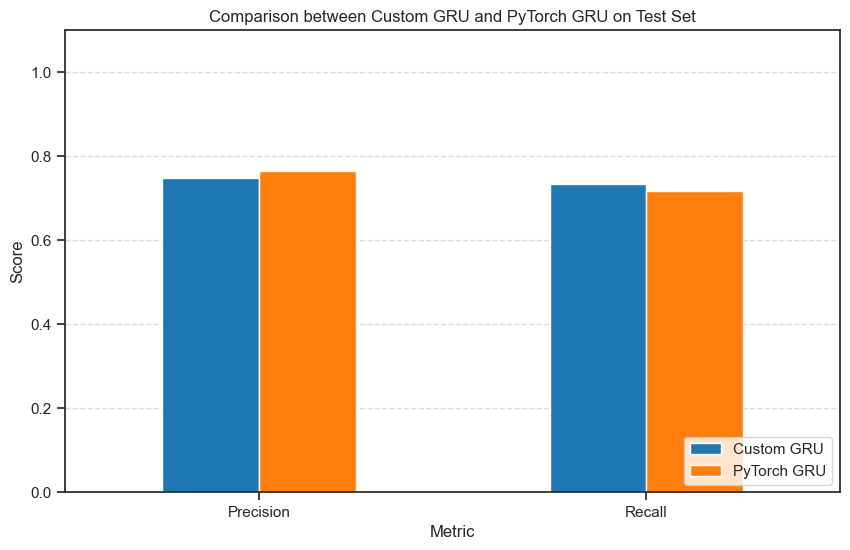

In [21]:
metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall'],
    'Custom GRU': [custom_metrics['precision'], custom_metrics['recall']],
    'PyTorch GRU': [pytorch_metrics['precision'], pytorch_metrics['recall']]
})

print(metrics_df.to_string(index=False))

# Plotting the comparison
metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Comparison between Custom GRU and PyTorch GRU on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()